In [680]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [681]:
df = pd.read_csv("14-income_evaluation.csv")

In [682]:
df.shape

(32561, 15)

In [683]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [684]:
col_names = ['age', 'workclass', 'finalweight', 'education', 'education_num', 'marital_status', 'occupation', 'relationship',
             'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

In [685]:
df.columns =col_names

In [686]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   finalweight     32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [687]:
categorical =[col for col in df.columns if df[col].dtype == 'object']
numerical = [col for col in df.columns if df[col].dtype != 'object']

In [688]:
for col in categorical:
   print( df[col].value_counts())

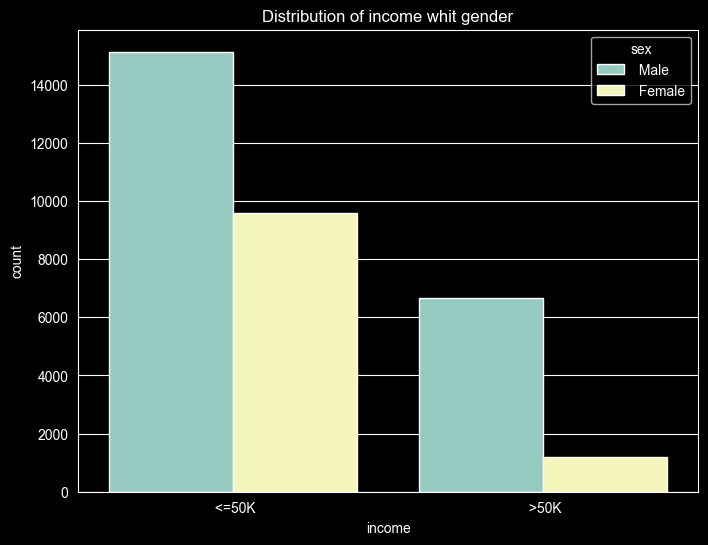

In [689]:
fig,ax =plt.subplots(figsize = (8,6))
ax=sns.countplot(x="income",data=df,hue="sex")
ax.set_title("Distribution of income whit gender")
plt.show()

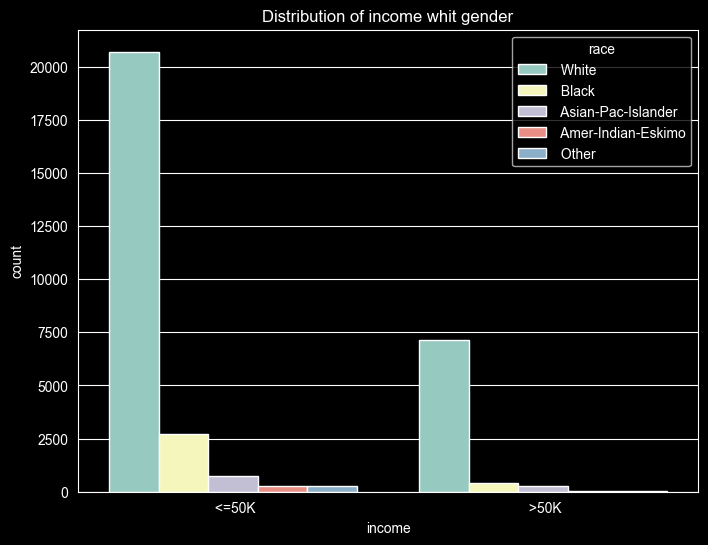

In [690]:
fig,ax =plt.subplots(figsize = (8,6))
ax=sns.countplot(x="income",data=df,hue="race")
ax.set_title("Distribution of income whit gender")
plt.show()

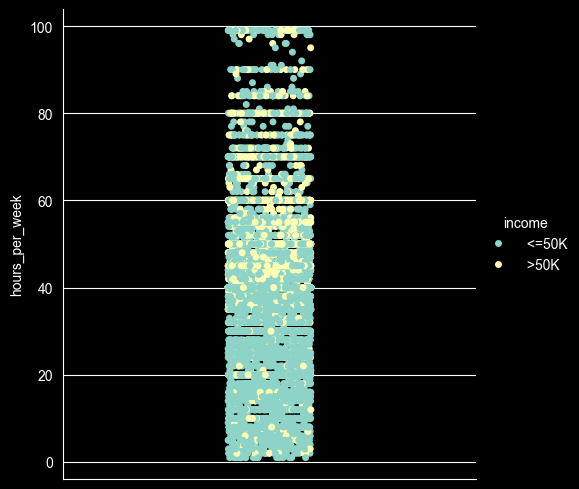

In [691]:
sns.catplot(y=df["hours_per_week"],hue = df["income"])
plt.show()


In [692]:
df.columns

Index(['age', 'workclass', 'finalweight', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='str')

In [693]:
df["workclass"].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [694]:
df["workclass"] = df["workclass"].replace(" ?" , np.nan)

In [695]:
df["workclass"].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [696]:
df["occupation"].unique()

<StringArray>
[     ' Adm-clerical',   ' Exec-managerial', ' Handlers-cleaners',
    ' Prof-specialty',     ' Other-service',             ' Sales',
      ' Craft-repair',  ' Transport-moving',   ' Farming-fishing',
 ' Machine-op-inspct',      ' Tech-support',                 ' ?',
   ' Protective-serv',      ' Armed-Forces',   ' Priv-house-serv']
Length: 15, dtype: str

In [697]:
df["occupation"]=df["occupation"].replace(" ?" , np.nan)

In [698]:
df["native_country"]=df["native_country"].replace(" ?" , np.nan)

In [699]:
df.isnull().sum()

age                  0
workclass         1836
finalweight          0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

In [700]:
#sns.pairplot(df, hue="income")
#plt.show()

In [701]:
X=df.drop("income",axis=1)
y=df["income"]

In [702]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

In [703]:
categorical =[col for col in X_train.columns if X_train[col].dtype == 'object']

In [704]:
X_train[categorical].isnull().sum()

Series([], dtype: float64)

In [705]:
for i in [X_train,X_test]: # burası nan değerlerin moda göre doldurulması
    i["workclass"]=i["workclass"].fillna(X_train["workclass"].mode()[0]) # modu bir list olarak döndürdüğü için 0. indisi alıyoruz
    i["occupation"]=i["occupation"].fillna(X_train["occupation"].mode()[0])
    i["native_country"]=i["native_country"].fillna(X_train["native_country"].mode()[0])


In [706]:
X_test[categorical].isnull().sum()

Series([], dtype: float64)

In [707]:
df[categorical].nunique()

Series([], dtype: float64)

native country için yapılacak encoding çok zor on-hot yapsan 41 kolon demek bu yüzden farklı bir yaklaşım yapılacak. mean encoding. yani o ülkeden gelenlerin % 70 50k dolardan fazla kazanıyorsa onu o kısma atıyoruz.

In [708]:
#

In [709]:
y_train_binary = y_train.apply(lambda x : 1 if x.strip() == ">50K" else 0) # x_trainde sadece 50k dan büyük ve küçük değerler olduğu için direkt onu kıyaslıyor başka kolon olsaydı kolonun adını yazmamız gerekirdi.

In [710]:
target_means=y_train_binary.groupby(X_train["native_country"]).mean() # bu satırda yapılan işi tanımlayacak olursak ya ülkelere göre guruplayıp yukarda oluşturdugumuz 1 ve 0 ları karşısına koyuyor. ardından koyduğu bu değerlerin ortalamasını buluyor

In [711]:
target_means


native_country
Cambodia                      0.333333
Canada                        0.309524
China                         0.241379
Columbia                      0.021739
Cuba                          0.257143
Dominican-Republic            0.021277
Ecuador                       0.166667
El-Salvador                   0.101449
England                       0.295082
France                        0.300000
Germany                       0.284091
Greece                        0.263158
Guatemala                     0.041667
Haiti                         0.093750
Holand-Netherlands            0.000000
Honduras                      0.100000
Hong                          0.272727
Hungary                       0.111111
India                         0.391304
Iran                          0.366667
Ireland                       0.187500
Italy                         0.354167
Jamaica                       0.090909
Japan                         0.395349
Laos                          0.200000
Mexico    

In [712]:
X_train['native_country_encoded']=X_train['native_country'].map(target_means)
X_train['native_country_encoded']=X_train['native_country_encoded'].fillna(y_train_binary.mean())

X_test['native_country_encoded']=X_test['native_country'].map(target_means)
X_test['native_country_encoded']=X_test['native_country_encoded'].fillna(y_train_binary.mean())

In [713]:
X_train.head()

,age,workclass,finalweight,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,native_country_encoded
32098,45,Private,170871,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,7298,0,60,United-States,0.245722
25206,47,State-gov,108890,HS-grad,9,Divorced,Adm-clerical,Unmarried,White,Female,1831,0,38,United-States,0.245722
23491,48,Private,187505,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0,0,50,United-States,0.245722
12367,29,Private,145592,HS-grad,9,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Guatemala,0.041667
7054,23,Private,203003,7th-8th,4,Never-married,Craft-repair,Not-in-family,White,Male,0,0,25,Germany,0.284091


In [714]:
X_train =X_train.drop("native_country",axis=1)
X_test =X_test.drop("native_country",axis=1)

In [715]:
one_hot_categories = ['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex']

In [716]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [717]:
encoder = ColumnTransformer(
    transformers=[
        ( 'transform_icin_isim_not_madder', OneHotEncoder(handle_unknown='ignore',sparse_output=False), one_hot_categories)
    ] ,remainder='passthrough' # diğer kolonlara dokunmasın diye bu remainder değerini veriyoruz.
)

In [718]:
X_train_enc =encoder.fit_transform(X_train)
X_test_enc =encoder.transform(X_test)

In [719]:
X_train_enc # burada numpy dizisine dönmül oluyor biz alt satırda dfe dönüştürüyoruz tekrar

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
        60.        ,  0.24572168],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        38.        ,  0.24572168],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        50.        ,  0.24572168],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        40.        ,  0.24572168],
       [ 0.        ,  1.        ,  0.        , ...,  0.        ,
        45.        ,  0.24572168],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        48.        ,  0.24572168]], shape=(22792, 65))

In [720]:
# get all encoded column names
columns = encoder.get_feature_names_out()

In [721]:
X_train = pd.DataFrame(X_train_enc, columns=columns, index=X_train.index)
X_test = pd.DataFrame(X_test_enc, columns=columns, index=X_test.index)

In [722]:
X_train.columns

Index(['transform_icin_isim_not_madder__workclass_ Federal-gov',
       'transform_icin_isim_not_madder__workclass_ Local-gov',
       'transform_icin_isim_not_madder__workclass_ Never-worked',
       'transform_icin_isim_not_madder__workclass_ Private',
       'transform_icin_isim_not_madder__workclass_ Self-emp-inc',
       'transform_icin_isim_not_madder__workclass_ Self-emp-not-inc',
       'transform_icin_isim_not_madder__workclass_ State-gov',
       'transform_icin_isim_not_madder__workclass_ Without-pay',
       'transform_icin_isim_not_madder__education_ 10th',
       'transform_icin_isim_not_madder__education_ 11th',
       'transform_icin_isim_not_madder__education_ 12th',
       'transform_icin_isim_not_madder__education_ 1st-4th',
       'transform_icin_isim_not_madder__education_ 5th-6th',
       'transform_icin_isim_not_madder__education_ 7th-8th',
       'transform_icin_isim_not_madder__education_ 9th',
       'transform_icin_isim_not_madder__education_ Assoc-acdm',
   

In [723]:
X_train.columns

Index(['transform_icin_isim_not_madder__workclass_ Federal-gov',
       'transform_icin_isim_not_madder__workclass_ Local-gov',
       'transform_icin_isim_not_madder__workclass_ Never-worked',
       'transform_icin_isim_not_madder__workclass_ Private',
       'transform_icin_isim_not_madder__workclass_ Self-emp-inc',
       'transform_icin_isim_not_madder__workclass_ Self-emp-not-inc',
       'transform_icin_isim_not_madder__workclass_ State-gov',
       'transform_icin_isim_not_madder__workclass_ Without-pay',
       'transform_icin_isim_not_madder__education_ 10th',
       'transform_icin_isim_not_madder__education_ 11th',
       'transform_icin_isim_not_madder__education_ 12th',
       'transform_icin_isim_not_madder__education_ 1st-4th',
       'transform_icin_isim_not_madder__education_ 5th-6th',
       'transform_icin_isim_not_madder__education_ 7th-8th',
       'transform_icin_isim_not_madder__education_ 9th',
       'transform_icin_isim_not_madder__education_ Assoc-acdm',
   

In [724]:
cols = X_train.columns

In [725]:
from sklearn.preprocessing import RobustScaler # treeler scaller atmeye pek gerek duymazlar ama biz scaller ettik
# bu defa farklı bir scaller kullandık farkı outliera daha daynaıklı bir scaller

scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [726]:
X_train = pd.DataFrame(X_train, columns=[cols])
X_test = pd.DataFrame(X_test, columns=[cols])

In [727]:
from sklearn.ensemble import RandomForestClassifier


In [728]:
rfc =RandomForestClassifier(n_estimators=10, random_state=15) # n_estimators kaç tane ağaç olacağını söyler
rfc.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [729]:
y_pred =rfc.predict(X_test)

In [730]:
from sklearn.metrics import classification_report , accuracy_score,confusion_matrix

In [731]:
print (accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.8482956290306071
[[6890  517]
 [ 965 1397]]
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      7407
        >50K       0.73      0.59      0.65      2362

    accuracy                           0.85      9769
   macro avg       0.80      0.76      0.78      9769
weighted avg       0.84      0.85      0.84      9769



In [732]:
rfc =RandomForestClassifier(n_estimators=100, random_state=15) # n_estimators kaç tane ağaç olacağını söyler
rfc.fit(X_train,y_train)
y_pred =rfc.predict(X_test)
print (accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.8546422356433616
[[6876  531]
 [ 889 1473]]
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7407
        >50K       0.74      0.62      0.67      2362

    accuracy                           0.85      9769
   macro avg       0.81      0.78      0.79      9769
weighted avg       0.85      0.85      0.85      9769



In [733]:
rfc.feature_importances_  # kolonalrın önemli olma oranlarını listler

array([5.86948083e-03, 5.92819446e-03, 7.71834128e-06, 1.11420821e-02,
       5.47836912e-03, 9.02457989e-03, 4.95195918e-03, 7.28838079e-05,
       1.31307915e-03, 1.75381534e-03, 8.17073623e-04, 2.85750399e-04,
       3.48189224e-04, 1.53961167e-03, 1.07880408e-03, 2.45245699e-03,
       3.06014470e-03, 1.06418670e-02, 2.66503020e-03, 7.14724635e-03,
       8.08808365e-03, 3.28595484e-05, 3.96490471e-03, 5.95817121e-03,
       5.98807638e-03, 2.83499574e-04, 6.18572859e-02, 9.87836968e-04,
       2.63805782e-02, 1.68775100e-03, 1.68465381e-03, 5.59884649e-03,
       2.49965342e-05, 8.37416717e-03, 1.85324301e-02, 3.82127988e-03,
       3.13200568e-03, 4.42128356e-03, 7.54398637e-03, 9.77432120e-05,
       1.39922136e-02, 3.11460587e-03, 7.37494753e-03, 5.13377748e-03,
       5.19738937e-03, 4.48361418e-02, 8.70027923e-03, 1.41561414e-03,
       9.58657802e-03, 4.45130797e-03, 1.07991701e-02, 1.39402872e-03,
       3.35400019e-03, 4.99209219e-03, 8.01672855e-04, 7.03217008e-03,
      

In [734]:
feature_scores = pd.Series(rfc.feature_importances_, index=X_train.columns).sort_values(ascending=False)
#modelinin hangi sütuna (özelliğe) ne kadar değer verdiğini hesaplayıp, önem sırasına göre diziyor.


In [735]:
feature_scores.tail(10 )

transform_icin_isim_not_madder__education_ 12th                      0.000817
transform_icin_isim_not_madder__race_ Other                          0.000802
transform_icin_isim_not_madder__education_ 5th-6th                   0.000348
transform_icin_isim_not_madder__education_ 1st-4th                   0.000286
transform_icin_isim_not_madder__marital_status_ Married-AF-spouse    0.000283
transform_icin_isim_not_madder__occupation_ Priv-house-serv          0.000098
transform_icin_isim_not_madder__workclass_ Without-pay               0.000073
transform_icin_isim_not_madder__education_ Preschool                 0.000033
transform_icin_isim_not_madder__occupation_ Armed-Forces             0.000025
transform_icin_isim_not_madder__workclass_ Never-worked              0.000008
dtype: float64

In [736]:
X_train = X_train.sort_index(axis=1)
X_test = X_test.sort_index(axis=1)

en önemsiz 10 kolonu silip bunun bizi nasıl etkilediğini bulmaya çalışıyoruz

In [737]:
X_train = X_train.drop([
    "transform_icin_isim_not_madder__workclass_ Never-worked",
    "transform_icin_isim_not_madder__occupation_ Armed-Forces",
    "transform_icin_isim_not_madder__education_ Preschool",
    "transform_icin_isim_not_madder__workclass_ Without-pay",
    "transform_icin_isim_not_madder__occupation_ Priv-house-serv",
    "transform_icin_isim_not_madder__marital_status_ Married-AF-spouse",
    "transform_icin_isim_not_madder__education_ 1st-4th",
    "transform_icin_isim_not_madder__education_ 5th-6th",
    "transform_icin_isim_not_madder__race_ Other",
    "transform_icin_isim_not_madder__education_ 12th"
], axis=1)

In [738]:
X_test = X_test.drop([
    "transform_icin_isim_not_madder__workclass_ Never-worked",
    "transform_icin_isim_not_madder__occupation_ Armed-Forces",
    "transform_icin_isim_not_madder__education_ Preschool",
    "transform_icin_isim_not_madder__workclass_ Without-pay",
    "transform_icin_isim_not_madder__occupation_ Priv-house-serv",
    "transform_icin_isim_not_madder__marital_status_ Married-AF-spouse",
    "transform_icin_isim_not_madder__education_ 1st-4th",
    "transform_icin_isim_not_madder__education_ 5th-6th",
    "transform_icin_isim_not_madder__race_ Other",
    "transform_icin_isim_not_madder__education_ 12th"
], axis=1)

In [740]:
rfc =RandomForestClassifier(n_estimators=100, random_state=15) # n_estimators kaç tane ağaç olacağını söyler
rfc.fit(X_train,y_train)
y_pred =rfc.predict(X_test)
print (accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.8554611526256526
[[6866  541]
 [ 871 1491]]
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7407
        >50K       0.73      0.63      0.68      2362

    accuracy                           0.86      9769
   macro avg       0.81      0.78      0.79      9769
weighted avg       0.85      0.86      0.85      9769



10 kolon silmem çok bir şey ifade etmedi

#hyperparameter tuning

In [752]:
rf_params = {"max_depth": [5, 8, 15, None, 10],
             "max_features": [5, 7, "auto", 8,"sqrt"],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500, 1000]}

In [753]:
from sklearn.model_selection import RandomizedSearchCV

In [754]:
rfc=RandomForestClassifier()

In [755]:
rscv = RandomizedSearchCV(estimator=rfc, param_distributions=rf_params,n_iter=10,cv=3,verbose=2,n_jobs=-1)
rscv.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END max_depth=5, max_features=7, min_samples_split=15, n_estimators=200; total time=   0.9s
[CV] END max_depth=5, max_features=7, min_samples_split=15, n_estimators=200; total time=   0.8s
[CV] END max_depth=5, max_features=7, min_samples_split=15, n_estimators=200; total time=   0.9s
[CV] END max_depth=None, max_features=auto, min_samples_split=8, n_estimators=1000; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_split=8, n_estimators=1000; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_split=8, n_estimators=1000; total time=   0.0s
[CV] END max_depth=15, max_features=sqrt, min_samples_split=20, n_estimators=100; total time=   0.9s
[CV] END max_depth=8, max_features=sqrt, min_samples_split=15, n_estimators=200; total time=   1.2s
[CV] END max_depth=8, max_features=sqrt, min_samples_split=15, n_estimators=200; total time=   1.2s
[CV] END max_depth=8, max_features=sqr

/Users/ummugulcaglar/Desktop/DataScience/data/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
6 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/ummugulcaglar/Desktop/DataScience/data/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/ummugulcaglar/Desktop/DataScience/data/.venv/lib/python3.14/site-packages/sklearn/base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 8, ...], 'max_features': [5, 7, ...], 'min_samples_split': [2, 8, ...], 'n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 

In [757]:
y_pred = rscv.predict(X_test)

In [756]:
rscv.best_params_

{'n_estimators': 500,
 'min_samples_split': 20,
 'max_features': 5,
 'max_depth': None}

In [758]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.91      7407
        >50K       0.76      0.63      0.69      2362

    accuracy                           0.86      9769
   macro avg       0.82      0.78      0.80      9769
weighted avg       0.86      0.86      0.86      9769

[[6937  470]
 [ 883 1479]]
